<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/3layer_nn_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 1. Imports
# =====================================
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

torch.manual_seed(42)

In [2]:
# =====================================
# 2. Load Real Dataset
# =====================================

import pandas as pd
import os

# Load data
data = fetch_california_housing()

X = data.data
y = data.target.reshape(-1,1)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: torch.Size([16512, 8])
Test shape: torch.Size([4128, 8])


In [3]:
# ======================================
# 3. Network Architecture
# ======================================
input_dim = X_train.shape[1]
hidden1 = 64
hidden2 = 32
output_dim = 1

# Xavier Initialization
W1 = torch.randn(input_dim, hidden1) * (2.0 / input_dim) ** 0.5
b1 = torch.zeros(1, hidden1)

W2 = torch.randn(hidden1, hidden2) * (2.0 / hidden1) ** 0.5
b2 = torch.zeros(1, hidden2)

W3 = torch.randn(hidden2, output_dim) * (2.0 / hidden2) ** 0.5
b3 = torch.zeros(1, output_dim)

In [4]:
def relu(x):
    return torch.clamp(x, min=0)

def relu_derivative(x):
    return (x > 0).float()

In [5]:
def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3   # Regression output
    return z1, a1, z2, a2, z3

In [6]:
# ======================================
# 4. Training
# ======================================
lr = 0.001
epochs = 2000
N = X_train.shape[0]

losses = []

for epoch in range(epochs):

    # Forward pass
    z1, a1, z2, a2, y_pred = forward(X_train)

    # Mean Squared Error (manual)
    loss = torch.mean((y_pred - y_train) ** 2)
    losses.append(loss.item())

    # ===============================
    # Manual Backpropagation
    # ===============================
    dL_dy = 2 * (y_pred - y_train) / N

    # Layer 3
    dL_dW3 = a2.t() @ dL_dy
    dL_db3 = torch.sum(dL_dy, dim=0, keepdim=True)

    # Layer 2
    dL_da2 = dL_dy @ W3.t()
    dL_dz2 = dL_da2 * relu_derivative(z2)
    dL_dW2 = a1.t() @ dL_dz2
    dL_db2 = torch.sum(dL_dz2, dim=0, keepdim=True)

    # Layer 1
    dL_da1 = dL_dz2 @ W2.t()
    dL_dz1 = dL_da1 * relu_derivative(z1)
    dL_dW1 = X_train.t() @ dL_dz1
    dL_db1 = torch.sum(dL_dz1, dim=0, keepdim=True)

    # ===============================
    # Manual SGD Update
    # ===============================
    W3 -= lr * dL_dW3
    b3 -= lr * dL_db3

    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2

    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 4.5568
Epoch 200, Loss: 0.9477
Epoch 400, Loss: 0.8072
Epoch 600, Loss: 0.7260
Epoch 800, Loss: 0.6737
Epoch 1000, Loss: 0.6373
Epoch 1200, Loss: 0.6104
Epoch 1400, Loss: 0.5897
Epoch 1600, Loss: 0.5731
Epoch 1800, Loss: 0.5595


In [7]:
with torch.no_grad():
    _, _, _, _, y_test_pred = forward(X_test)
    test_loss = torch.mean((y_test_pred - y_test) ** 2)

print("Test MSE:", test_loss.item())

Test MSE: 0.5763168931007385


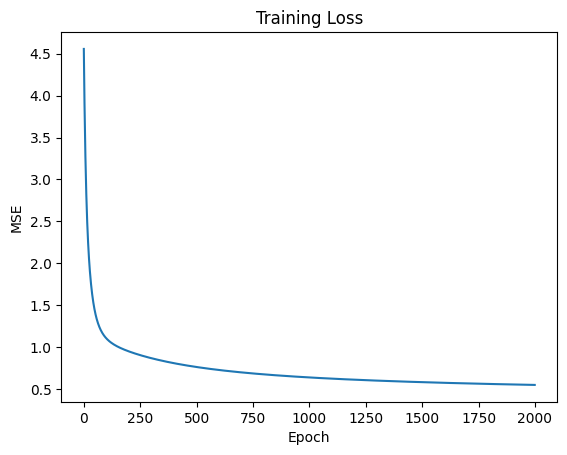

In [8]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()